In [68]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pickle as pkl
from sklearn import preprocessing

%matplotlib inline

In [69]:
a= 'C:\\Users\\HP\\Desktop\\My_Data_set_files\\bank.csv'
df= pd.read_csv(a, sep= ',')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [70]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [71]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [72]:
df.corr()

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


# Data Visualization

<AxesSubplot:title={'center':'Age and marital distribution'}, xlabel='marital', ylabel='age'>

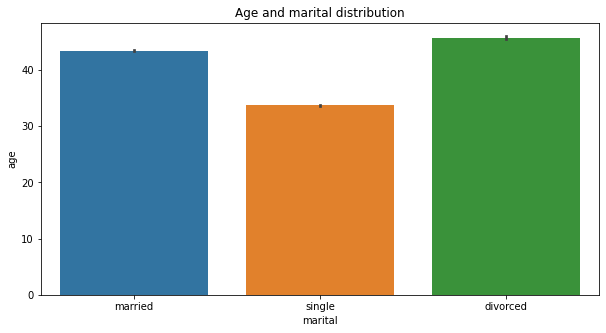

In [73]:
plt.figure(figsize = (10,5))
plt.title('Age and marital distribution')
sns.barplot(x = df['marital'], y =df['age'])

In [74]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

# Feature Engineering

In [75]:
df=df.drop(['education', 'default', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'month'], axis= 1)
df

,age,job,marital,balance,housing,loan,contact,day,deposit
0,58,management,married,2143,yes,no,unknown,5,no
1,44,technician,single,29,yes,no,unknown,5,no
2,33,entrepreneur,married,2,yes,yes,unknown,5,no
3,47,blue-collar,married,1506,yes,no,unknown,5,no
4,33,unknown,single,1,no,no,unknown,5,no
...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,825,no,no,cellular,17,yes
45207,71,retired,divorced,1729,no,no,cellular,17,yes
45208,72,retired,married,5715,no,no,cellular,17,yes
45209,57,blue-collar,married,668,no,no,telephone,17,no


In [87]:
le = preprocessing.LabelEncoder()
df['marital'] = le.fit_transform(df['marital'])
df['job'] = le.fit_transform(df['job'])
df['housing'] = le.fit_transform(df['housing'])
df['contact'] = le.fit_transform(df['contact'])
df['deposit'] = le.fit_transform(df['deposit'])
df

,age,job,marital,balance,housing,loan,contact,day,deposit,label
0,58,4,1,2143,1,no,2,5,0,1
1,44,9,2,29,1,no,2,5,0,2
2,33,2,1,2,1,yes,2,5,0,1
3,47,1,1,1506,1,no,2,5,0,1
4,33,11,2,1,0,no,2,5,0,2
...,...,...,...,...,...,...,...,...,...,...
45206,51,9,1,825,0,no,0,17,1,1
45207,71,5,0,1729,0,no,0,17,1,0
45208,72,5,1,5715,0,no,0,17,1,1
45209,57,1,1,668,0,no,1,17,0,1


In [88]:
df.dropna()

,age,job,marital,balance,housing,loan,contact,day,deposit,label
0,58,4,1,2143,1,no,2,5,0,1
1,44,9,2,29,1,no,2,5,0,2
2,33,2,1,2,1,yes,2,5,0,1
3,47,1,1,1506,1,no,2,5,0,1
4,33,11,2,1,0,no,2,5,0,2
...,...,...,...,...,...,...,...,...,...,...
45206,51,9,1,825,0,no,0,17,1,1
45207,71,5,0,1729,0,no,0,17,1,0
45208,72,5,1,5715,0,no,0,17,1,1
45209,57,1,1,668,0,no,1,17,0,1


In [89]:
df.isnull().sum()

age        0
job        0
marital    0
balance    0
housing    0
loan       0
contact    0
day        0
deposit    0
label      0
dtype: int64

In [90]:
X= df.drop(['loan'], axis= 1)
X

,age,job,marital,balance,housing,contact,day,deposit,label
0,58,4,1,2143,1,2,5,0,1
1,44,9,2,29,1,2,5,0,2
2,33,2,1,2,1,2,5,0,1
3,47,1,1,1506,1,2,5,0,1
4,33,11,2,1,0,2,5,0,2
...,...,...,...,...,...,...,...,...,...
45206,51,9,1,825,0,0,17,1,1
45207,71,5,0,1729,0,0,17,1,0
45208,72,5,1,5715,0,0,17,1,1
45209,57,1,1,668,0,1,17,0,1


In [92]:
y= df['loan']
y

0         no
1         no
2        yes
3         no
4         no
        ... 
45206     no
45207     no
45208     no
45209     no
45210     no
Name: loan, Length: 45211, dtype: object

# Machine Learning Modelling

In [93]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state= 100, test_size= 0.2)

In [95]:
from sklearn.linear_model import LogisticRegression
lgr= LogisticRegression()
lgr.fit(X_train, y_train)
lgr.score(X_test, y_test)*100

83.93232334402299

# Making prediction using the fitted test variable

In [99]:
predict= lgr.predict(X_test)
predict

array(['no', 'no', 'no', ..., 'no', 'no', 'no'], dtype=object)

# Saving as a pickle file

In [101]:
with open('bankloan_model_selection.pkl', 'wb') as file:
    pkl.dump('lgr', file)
